# Considering constraints and multiple objectives

We implemented two solvers for the capacitated p-median problem:
- Minimizing demand-weighted service distance
- Maximizing facility dispersion

In [1]:
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Any
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import statistics

@dataclass
class Instance:
    instance_id: int
    best_known: float
    n: int
    p: int
    capacity: int
    customer_ids: np.ndarray
    xy: np.ndarray
    demand: np.ndarray

def load_instances(path: str) -> Dict[int, Instance]:
    with open(path, "r", encoding="utf-8") as f:
        lines = [ln.strip() for ln in f if ln.strip()]

    i = 0
    instances = {}
    while i < len(lines):
        head = lines[i].split()
        instance_id = int(head[0])
        best_known = float(head[1])
        i += 1

        n, p, cap = map(int, lines[i].split())
        i += 1

        ids, xy, dem = [], [], []
        for _ in range(n):
            cid, x, y, d = map(int, lines[i].split())
            ids.append(cid)
            xy.append((x, y))
            dem.append(d)
            i += 1

        instances[instance_id] = Instance(
            instance_id=instance_id,
            best_known=best_known,
            n=n,
            p=p,
            capacity=cap,
            customer_ids=np.array(ids, dtype=int),
            xy=np.array(xy, dtype=float),
            demand=np.array(dem, dtype=float),
        )

    return instances
instances = load_instances("p_median_capacitated.txt")
print(len(instances))

18


# NSGA helper functions

In [11]:
class Individual:
    """Simple data structure to hold a chromosome and its evaluation metrics."""
    def __init__(self, facilities: List[int]):
        self.facilities = np.array(facilities)
        self.distance = float('inf')
        self.dispersion = 0.0
        self.violation = float('inf')
        self.rank = -1
        self.crowding_distance = 0.0

    def dominates(self, other) -> bool:
        # Less violation is always dominant
        if self.violation < other.violation:
            return True
        elif self.violation > other.violation:
            return False
        
        # Minimize distance, Maximize dispersion
        better_or_eq = (self.distance <= other.distance) and (self.dispersion >= other.dispersion)
        strictly_better = (self.distance < other.distance) or (self.dispersion > other.dispersion)
        
        return better_or_eq and strictly_better


def evaluate(ind: Individual, inst, dist_matrix: np.ndarray, customer_order: np.ndarray):
    facilities = ind.facilities
    dist = 0.0
    caps = np.full(inst.p, inst.capacity, dtype=float)
    
    # Calculate Distance objective and Violation constraint
    for c in customer_order:
        dists_to_open = dist_matrix[c, facilities]
        demand = inst.demand[c]
        
        valid_mask = caps >= demand
        if np.any(valid_mask):
            valid_indices = np.where(valid_mask)[0]
            best_idx = valid_indices[np.argmin(dists_to_open[valid_mask])]
            dist += dists_to_open[best_idx]
            caps[best_idx] -= demand
        else:
            best_idx = np.argmin(dists_to_open)
            dist += dists_to_open[best_idx]
            caps[best_idx] -= demand
            
    ind.distance = dist
    ind.violation = np.sum(np.maximum(0, -caps))
    
    # Calculate Dispersion objective
    if len(facilities) > 1:
        # Get distances between all unique pairs of chosen facilities
        pair_dists = [dist_matrix[f1, f2] for f1, f2 in combinations(facilities, 2)]
        ind.dispersion = min(pair_dists)
    else:
        ind.dispersion = 0.0


def initialize_population(pop_size: int, inst, dist_matrix: np.ndarray, customer_order: np.ndarray) -> List[Individual]:
    pop = []
    nodes = list(range(inst.n))
    for _ in range(pop_size):
        facs = random.sample(nodes, inst.p)
        ind = Individual(facs)
        evaluate(ind, inst, dist_matrix, customer_order)
        pop.append(ind)
    return pop

def initialize_unique_population(pop_size: int, inst, seen_solutions: set, dist_matrix: np.ndarray, customer_order: np.ndarray) -> List[Individual]:
    pop = []
    nodes = list(range(inst.n))
    while len(pop) < pop_size:
        facs = random.sample(nodes, inst.p)
        facs_key = tuple(sorted(facs))
        
        if facs_key not in seen_solutions:
            seen_solutions.add(facs_key)
            ind = Individual(facs)
            evaluate(ind, inst, dist_matrix, customer_order)
            pop.append(ind)
    return pop


def crossover(p1: Individual, p2: Individual, inst) -> Individual:
    union_facs = list(set(p1.facilities) | set(p2.facilities))
    if len(union_facs) < inst.p:
        remaining = list(set(range(inst.n)) - set(union_facs))
        union_facs += random.sample(remaining, inst.p - len(union_facs))
    
    child_facs = random.sample(union_facs, inst.p)
    return Individual(child_facs)


def mutate(ind: Individual, inst, mutation_rate: float):
    if random.random() < mutation_rate:
        facs = set(ind.facilities)
        remove_fac = random.choice(list(facs))
        facs.remove(remove_fac)
        candidates = list(set(range(inst.n)) - facs)
        facs.add(random.choice(candidates))
        ind.facilities = np.array(list(facs))


def fast_non_dominated_sort(pop: List[Individual]) -> List[List[Individual]]:
    fronts = [[]]
    for p in pop:
        p.domination_count = 0
        p.dominated_solutions = []
        for q in pop:
            if p.dominates(q):
                p.dominated_solutions.append(q)
            elif q.dominates(p):
                p.domination_count += 1
        if p.domination_count == 0:
            p.rank = 0
            fronts[0].append(p)
    
    i = 0
    while len(fronts[i]) > 0:
        next_front = []
        for p in fronts[i]:
            for q in p.dominated_solutions:
                q.domination_count -= 1
                if q.domination_count == 0:
                    q.rank = i + 1
                    next_front.append(q)
        i += 1
        fronts.append(next_front)
    return fronts[:-1]


def calculate_crowding_distance(front: List[Individual]):
    l = len(front)
    if l == 0: return
    for ind in front:
        ind.crowding_distance = 0.0
        
    for obj in ['distance', 'dispersion']: 
        front.sort(key=lambda x: getattr(x, obj))
        front[0].crowding_distance = float('inf')
        front[-1].crowding_distance = float('inf')
        
        obj_min = getattr(front[0], obj)
        obj_max = getattr(front[-1], obj)
        val_range = obj_max - obj_min
        if val_range == 0: continue
        
        for i in range(1, l - 1):
            front[i].crowding_distance += (getattr(front[i+1], obj) - getattr(front[i-1], obj)) / val_range


def tournament_selection(pop: List[Individual]) -> Individual:
    i, j = random.sample(pop, 2)
    if i.rank < j.rank:
        return i
    elif i.rank > j.rank:
        return j
    else:
        return i if i.crowding_distance > j.crowding_distance else j

# NSGA II implementation

In [3]:
def solve_nsga2(inst, pop_size=100, generations=100, mutation_rate=0.1, verbose=True, unique=True) -> List[Individual]:
    # Precompute distance matrix and customer demands
    dist_matrix = np.linalg.norm(inst.xy[:, None, :] - inst.xy[None, :, :], axis=-1)
    customer_order = np.argsort(-inst.demand)

    # Track evaluated solutions using a sorted tuple as the hashable key
    seen_solutions = set()
    nodes = list(range(inst.n))
    
    # Initialize and sort first population
    if unique:
        pop = initialize_unique_population(pop_size, inst, seen_solutions, dist_matrix, customer_order)
    else:
        pop = initialize_population(pop_size, inst, dist_matrix, customer_order) # Does not guarantee unique population
    
    fast_non_dominated_sort(pop)
    
    # Evolution loop
    for gen in range(generations):
        offspring = []
        while len(offspring) < pop_size:
            p1 = tournament_selection(pop)
            p2 = tournament_selection(pop)

            child = crossover(p1, p2, inst)
            mutate(child, inst, mutation_rate)
            
            # Enforce uniqueness
            if unique:
                child_key = tuple(sorted(child.facilities))
                attempts = 0
                while child_key in seen_solutions and attempts < 10:
                    # Force a mutation to break out of duplicate state
                    mutate(child, inst, mutation_rate=1.0) 
                    child_key = tuple(sorted(child.facilities))
                    attempts += 1

                if child_key in seen_solutions:
                    # Inject a completely random unique alien if still stuck
                    while child_key in seen_solutions:
                        alien_facs = random.sample(nodes, inst.p)
                        child = Individual(alien_facs)
                        child_key = tuple(sorted(child.facilities))
                seen_solutions.add(child_key)

            evaluate(child, inst, dist_matrix, customer_order)
            offspring.append(child)
            
        combined = pop + offspring
        fronts = fast_non_dominated_sort(combined)
        
        new_pop = []
        for front in fronts:
            calculate_crowding_distance(front)
            if len(new_pop) + len(front) <= pop_size:
                new_pop.extend(front)
            else:
                front.sort(key=lambda x: x.crowding_distance, reverse=True)
                new_pop.extend(front[:pop_size - len(new_pop)])
                break
        pop = new_pop
        
        if verbose:
            feasible = [p for p in pop if p.violation == 0]
            best_dist = min([p.distance for p in feasible]) if feasible else "None"
            if gen % 10 == 0:
                print(f"Generation {gen} | Best Feasible Distance: {best_dist}")
            
    return pop

# SPEA helper functions

In [4]:
def pairwise_dist_matrix(xy: np.ndarray) -> np.ndarray:
    diff = xy[:, None, :] - xy[None, :, :]
    return np.sqrt(np.sum(diff * diff, axis=2))

def greedy_capacity_assignment(
    medians: np.ndarray,
    demand: np.ndarray,
    dist: np.ndarray,
    capacity: float,
) -> Tuple[bool, float, float]:
    k = len(medians)
    remaining = np.full(k, float(capacity))
    total_weighted = 0.0
    total_unweighted = 0.0

    order = np.argsort(-demand)  # large demands first

    for customer in order:
        d = demand[customer]
        feasible = np.where(remaining >= d)[0]
        if feasible.size == 0:
            return False, float("inf"), float("inf")

        local_d = dist[customer, medians[feasible]]
        j = int(np.argmin(local_d))
        pick_local = int(feasible[j])
        chosen_dist = float(local_d[j])

        total_unweighted += chosen_dist
        total_weighted += float(d) * chosen_dist
        remaining[pick_local] -= d

    return True, total_weighted, total_unweighted

def dispersion_min_pair(medians: np.ndarray, dist: np.ndarray) -> float:
    if len(medians) < 2:
        return 0.0
    sub = dist[np.ix_(medians, medians)]
    upper = sub[np.triu_indices(len(medians), k=1)]
    return float(np.min(upper))

def evaluate_solution(sol: Tuple[int, ...], inst: Instance, dist: np.ndarray):
    med = np.array(sol, dtype=int)

    feasible, weighted_cost, unweighted_cost = greedy_capacity_assignment(
        med, inst.demand, dist, inst.capacity
    )
    if not feasible:
        return float("inf"), float("-inf"), (float("inf"), float("inf")), float("inf")

    disp = dispersion_min_pair(med, dist)

    # SPEA minimization objectives
    obj = (weighted_cost, -disp)
    return weighted_cost, disp, obj, unweighted_cost
def dominates(a, b) -> bool:
    return all(x <= y for x, y in zip(a, b)) and any(x < y for x, y in zip(a, b))

def strength_raw_fitness(objs: List[Tuple[float, float]]):
    n = len(objs)
    S = [0] * n
    R = [0] * n

    for i in range(n):
        if math.isinf(objs[i][0]):
            continue
        for j in range(n):
            if i != j and dominates(objs[i], objs[j]):
                S[i] += 1
    for i in range(n):
        if math.isinf(objs[i][0]):
            R[i] = 10**9
            continue
        total = 0
        for j in range(n):
            if i != j and dominates(objs[j], objs[i]):
                total += S[j]
        R[i] = total

    return S, R

def nd_indices(objs: List[Tuple[float, float]]):
    idx = []
    for i in range(len(objs)):
        if math.isinf(objs[i][0]):
            continue
        dom = False
        for j in range(len(objs)):
            if i != j and dominates(objs[j], objs[i]):
                dom = True
                break
        if not dom:
            idx.append(i)
    return idx

def truncate_by_spacing(indices: List[int],
                        objs: List[Tuple[float, float]],
                        target_size: int) -> List[int]:
    keep = indices[:]

    while len(keep) > target_size:
        points = np.array([objs[i] for i in keep], dtype=float)

        # Normalize each objective to [0, 1] to avoid scale dominance
        mins = points.min(axis=0)
        maxs = points.max(axis=0)
        span = np.maximum(maxs - mins, 1e-12)  # avoid divide-by-zero
        points = (points - mins) / span

        # Pairwise distances in normalized objective space
        diff = points[:, None, :] - points[None, :, :]
        dmat = np.sqrt(np.sum(diff * diff, axis=2))
        np.fill_diagonal(dmat, np.inf)

        # Crowding measure: nearest neighbor distance
        nearest = np.min(dmat, axis=1)

        # Remove the most crowded (smallest nearest-neighbor distance)
        remove_pos = int(np.argmin(nearest))
        keep.pop(remove_pos)

    return keep

def repair_solution(sol: List[int], n: int, p: int) -> Tuple[int, ...]:
    # Remove duplicates
    sol = list(dict.fromkeys(sol))

    if len(sol) < p:
        chosen = set(sol)
        available = [x for x in range(n) if x not in chosen]
        # sample without replacement
        sol.extend(random.sample(available, p - len(sol)))
    elif len(sol) > p:
        sol = random.sample(sol, p)

    return tuple(sorted(sol))

def spea_crossover(a: Tuple[int, ...], b: Tuple[int, ...], n: int, p: int) -> Tuple[int, ...]:
    common = set(a) & set(b)
    pool = list(set(a) | set(b))

    child = list(common)
    child_set = set(child)

    random.shuffle(pool)
    for g in pool:
        if len(child) >= p:
            break
        if g not in child_set:
            child.append(g)
            child_set.add(g)

    return repair_solution(child, n, p)

def spea_mutate(sol: Tuple[int, ...], n: int, p: int, pm: float) -> Tuple[int, ...]:
    if random.random() >= pm:
        return sol

    s = list(sol)
    out = random.choice(s)
    s.remove(out)

    chosen = set(s)
    candidates = [x for x in range(n) if x not in chosen]
    s.append(random.choice(candidates))

    return tuple(sorted(s))

def tournament(pop: List[Tuple[int, ...]], fit: List[float]) -> Tuple[int, ...]:
    i, j = random.sample(range(len(pop)), 2)
    return pop[i] if fit[i] <= fit[j] else pop[j]

def random_solution(n: int, p: int) -> Tuple[int, ...]:
    return tuple(sorted(random.sample(range(n), p)))


# SPEA II implementation

In [5]:
def spea(
    inst: Instance,
    pop_size: int = 80,
    archive_size: int = 40,
    generations: int = 120,
    pm: float = 0.2,
    seed: int = 42,
):
    random.seed(seed)
    np.random.seed(seed)

    dist = pairwise_dist_matrix(inst.xy)

    P = [random_solution(inst.n, inst.p) for _ in range(pop_size)]
    A = []
    history = []

    for gen in range(generations):
        U = P + A

        eval_full = [evaluate_solution(sol, inst, dist) for sol in U]
        objs = [x[2] for x in eval_full]   # (service, -disp)
        service = [x[0] for x in eval_full]
        disp = [x[1] for x in eval_full]

        _, R = strength_raw_fitness(objs)

        # Manage archive
        nd = nd_indices(objs)
        if len(nd) > archive_size:
            selected_idx = truncate_by_spacing(nd, objs, archive_size)
        else:
            selected_idx = nd[:]
            if len(selected_idx) < archive_size:
                rest = [i for i in range(len(U)) if i not in selected_idx]
                rest.sort(key=lambda i: R[i])
                selected_idx += rest[: archive_size - len(selected_idx)]

        # New archive
        A = [U[i] for i in selected_idx]

        # Fitness values for archive members, derived from the combined set U
        A_fit = [R[i] for i in selected_idx]

        new_P = []
        while len(new_P) < pop_size:
            p1 = tournament(A, A_fit)
            p2 = tournament(A, A_fit)
            c = spea_crossover(p1, p2, inst.n, inst.p)
            c = spea_mutate(c, inst.n, inst.p, pm)
            new_P.append(c)

        P = new_P

        finite_service = [v for v in service if not math.isinf(v)]
        best_service = min(finite_service) if finite_service else float("inf")
        best_disp = max([v for v in disp if v > -1e20], default=float("-inf"))
        history.append((gen, best_service, best_disp, len(nd)))

    # Evaluate final archive once
    final_eval = [evaluate_solution(sol, inst, dist) for sol in A]
    final_data = [
    {
        "solution": sol,
        "service": e[0],                 # weighted
        "dispersion": e[1],
        "obj": e[2],
        "unweighted_service": e[3],      # comparable to best_known
    }
    for sol, e in zip(A, final_eval)
    if not math.isinf(e[0])
]

    objs = [d["obj"] for d in final_data]
    nd = nd_indices(objs)
    pareto = [final_data[i] for i in nd]
    pareto.sort(key=lambda z: (z["service"], -z["dispersion"]))

    return pareto, history

# Testing

### Function that prints and plots out a solution. The facilities and their connected customers.

In [10]:
def visualize_assignments(ins, solution):
    print("Facility assignments:")
    
    # Re-calculate distance matrix for the final assignment
    dist_matrix = pairwise_dist_matrix(ins.xy)
    best_medians = np.array(solution)
    
    # Replicate the greedy capacity assignment to see who goes where
    k = len(best_medians)
    remaining = np.full(k, float(ins.capacity))
    
    # Dictionary to hold medians and assigned customers
    clusters = {med: [] for med in best_medians}
    
    order = np.argsort(-ins.demand)  # Large demands first
    
    for customer in order:
        d = ins.demand[customer]
        feasible = np.where(remaining >= d)[0]
        
        if feasible.size > 0:
            local_d = dist_matrix[customer, best_medians[feasible]]
            j = int(np.argmin(local_d))
            pick_local = int(feasible[j])
            assigned_median = best_medians[pick_local]
            
            # Record the assignment and update capacity
            clusters[assigned_median].append(int(customer))
            remaining[pick_local] -= d

    # Print the formatted output
    for med in best_medians:
        med_x, med_y = ins.xy[med]
        customers = sorted(clusters[med])
        used_cap = ins.capacity - remaining[np.where(best_medians == med)[0][0]]
        
        print(f"Facility Node {med}: Coordinates (X: {med_x:.2f}, Y: {med_y:.2f})")
        print(f"  -> Capacity Used: {used_cap:.2f} / {ins.capacity:.2f}")
        print(f"  -> Assigned Customers ({len(customers)}): {customers}\n")

    # Plot
    plt.figure(figsize=(12, 8))
    
    # Plot the selected medians as large red stars
    plt.scatter(ins.xy[best_medians, 0], ins.xy[best_medians, 1], 
                c='red', marker='*', s=300, edgecolor='black', label='Medians', zorder=3)

    # Generate distinct colors for each facility cluster
    colors = plt.cm.tab10(np.linspace(0, 1, len(best_medians)))
    median_color_map = {med: colors[i % len(colors)] for i, med in enumerate(best_medians)}

    # Loop through each cluster to draw lines and color customers
    for med, customers in clusters.items():
        color = median_color_map[med]
        m_coords = ins.xy[med]
        
        for customer in customers:
            c_coords = ins.xy[customer]
            
            # Draw line connecting customer to median
            plt.plot([c_coords[0], m_coords[0]], [c_coords[1], m_coords[1]], 
                     color=color, alpha=0.4, linewidth=1, zorder=1)
            
            # Draw the customer node in the same color as its median
            plt.scatter(c_coords[0], c_coords[1], c=[color], s=30, zorder=2)

### Test NSGA

Run 1...
Run 2...
Run 3...
Testing instance 4 using NSGA II (unique=False)
Average distance over 3 runs: 694.87 (best known: 651.0)
Average diff from known best: 6.31%
Best distance from all runs: 684.7785075250158
Best dispersion from all runs: 32.89376840679705
Best solution: [ 2  7  8 15 22]

Facility assignments:
Facility Node 2: Coordinates (X: 66.00, Y: 78.00)
  -> Capacity Used: 119.00 / 120.00
  -> Assigned Customers (11): [2, 4, 5, 14, 23, 30, 33, 35, 37, 46, 47]

Facility Node 7: Coordinates (X: 13.00, Y: 50.00)
  -> Capacity Used: 98.00 / 120.00
  -> Assigned Customers (10): [0, 1, 7, 11, 12, 13, 20, 41, 42, 48]

Facility Node 8: Coordinates (X: 19.00, Y: 83.00)
  -> Capacity Used: 105.00 / 120.00
  -> Assigned Customers (11): [3, 6, 8, 27, 31, 34, 36, 38, 39, 43, 45]

Facility Node 15: Coordinates (X: 44.00, Y: 39.00)
  -> Capacity Used: 116.00 / 120.00
  -> Assigned Customers (11): [10, 15, 18, 19, 24, 26, 28, 29, 32, 40, 44]

Facility Node 22: Coordinates (X: 80.00, Y: 24

[np.float64(700.954117381264),
 np.float64(698.8684900364681),
 np.float64(684.7785075250158)]

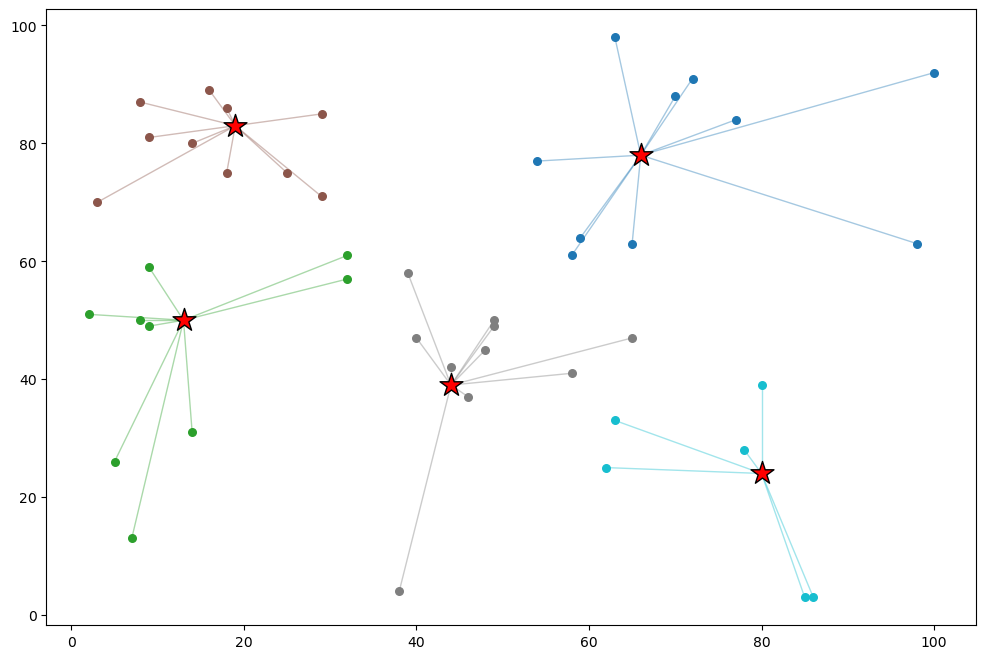

In [7]:
def test_nsga(runs, instance=1, unique=False, quiet=False):
    # Initialize parameters
    distances = []
    ins_key = sorted(instances.keys())[instance]
    ins = instances[ins_key]
    prev_best = 9999999999
    prev_best_disp = 0
    prev_best_sol = []

    # Run algorithm n_tests times keeping track of the best solution and makespans
    for i in range(runs):
        if not quiet: print(f"Run {i+1}...")
        final_population = solve_nsga2(ins, pop_size=50, generations=150, mutation_rate=0.2, verbose=False, unique=unique)
        feasible_sols = [p for p in final_population if p.violation == 0]
        if feasible_sols:
            best_solution = min(feasible_sols, key=lambda x: x.distance)
            diff = 100 * (1-(ins.best_known / best_solution.distance))
            if best_solution.distance < prev_best:
                prev_best = best_solution.distance
                prev_best_disp = best_solution.dispersion
                prev_best_sol = best_solution.facilities
            distances.append(best_solution.distance)
        else:
            print("No strictly feasible solution found.\n")
        

    # Calculate interesting statistics
    avg = statistics.mean(distances)
    avg_diff = 100 * (1 - (ins.best_known / avg))

    # Print results
    print(f'Testing instance {instance+1} using NSGA II (unique={unique})')
    print(f'Average distance over {runs} runs: {avg:.2f} (best known: {ins.best_known})')
    print(f'Average diff from known best: {avg_diff:.2f}%')
    print(f'Best distance from all runs: {prev_best}')
    print(f'Best dispersion from all runs: {prev_best_disp}')
    print(f'Best solution: {prev_best_sol}\n')
    if not quiet: visualize_assignments(ins, prev_best_sol)
    return distances
test_nsga(3, 3, False)

### Test SPEA

Run 1...
Run 2...
Run 3...
Testing instance 4 using SPEA II
Average distance over 3 runs: 702.59 (best known: 651.0)
Average diff from known best: 7.34%
Best distance from all runs: 689.32598422383
Best dispersion from all runs: 26.92582403567252
Best solution: (2, 10, 12, 21, 45)

Facility assignments:
Facility Node 2: Coordinates (X: 66.00, Y: 78.00)
  -> Capacity Used: 119.00 / 120.00
  -> Assigned Customers (11): [2, 4, 5, 14, 23, 30, 33, 35, 37, 46, 47]

Facility Node 10: Coordinates (X: 40.00, Y: 47.00)
  -> Capacity Used: 115.00 / 120.00
  -> Assigned Customers (10): [10, 15, 18, 20, 26, 28, 29, 32, 40, 41]

Facility Node 12: Coordinates (X: 8.00, Y: 50.00)
  -> Capacity Used: 68.00 / 120.00
  -> Assigned Customers (8): [0, 1, 7, 11, 12, 13, 42, 48]

Facility Node 21: Coordinates (X: 63.00, Y: 33.00)
  -> Capacity Used: 110.00 / 120.00
  -> Assigned Customers (10): [9, 16, 17, 19, 21, 22, 24, 25, 44, 49]

Facility Node 45: Coordinates (X: 14.00, Y: 80.00)
  -> Capacity Used: 105

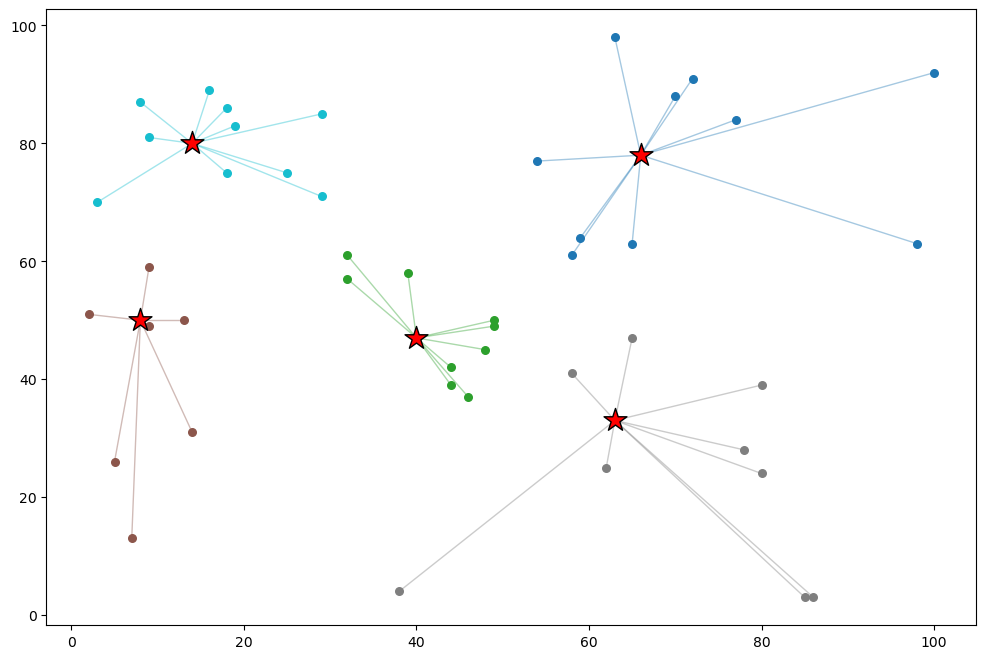

In [8]:
def test_spea(runs, instance=1, quiet=False):
    # Initialize parameters
    distances = []
    ins_key = sorted(instances.keys())[instance]
    ins = instances[ins_key]
    prev_best_dist = 9999999999
    prev_best_disp = 0
    prev_best_sol = []

    # Run algorithm n_tests times keeping track of the best solution and makespans
    for i in range(runs):
        if not quiet: print(f"Run {i+1}...")
        pareto, history = spea(
                ins,
                pop_size=50,
                archive_size=40,
                generations=150,
                pm=0.2,
                seed=random.randint(0, 10000),
                )
        # Find the dictionary with the maximum unweighted_service
        best_entry = min(pareto, key=lambda x: x['unweighted_service'])

        # Extract specific values
        best_value = best_entry['unweighted_service']
        best_value_disp = best_entry['dispersion']
        best_solution = best_entry['solution']

        diff = 100 * (1-(ins.best_known / best_value))
        if best_value < prev_best_dist:
            prev_best_dist = best_value
            prev_best_disp = best_value_disp
            prev_best_sol = best_solution
        distances.append(best_value)

    # Calculate interesting statistics
    avg = statistics.mean(distances)
    avg_diff = 100 * (1 - (ins.best_known / avg))

    # Print results
    print(f'Testing instance {instance+1} using SPEA II')
    print(f'Average distance over {runs} runs: {avg:.2f} (best known: {ins.best_known})')
    print(f'Average diff from known best: {avg_diff:.2f}%')
    print(f'Best distance from all runs: {prev_best_dist}')
    print(f'Best dispersion from all runs: {prev_best_disp}')
    print(f'Best solution: {prev_best_sol}\n')
    if not quiet: visualize_assignments(ins, prev_best_sol)
    return distances
n = test_spea(3, 3)

### Run several tests that compare the models

Running tests for Instance 1 over 5 runs...
Testing instance 1 using NSGA II (unique=True)
Average distance over 5 runs: 750.04 (best known: 713.0)
Average diff from known best: 4.94%
Best distance from all runs: 750.0401795210161
Best dispersion from all runs: 35.17101079013795
Best solution: [43 11  9 47 18]

Testing instance 1 using NSGA II (unique=False)
Average distance over 5 runs: 760.12 (best known: 713.0)
Average diff from known best: 6.20%
Best distance from all runs: 750.0401795210161
Best dispersion from all runs: 35.17101079013795
Best solution: [ 9 43 11 47 18]

Testing instance 1 using SPEA II
Average distance over 5 runs: 767.81 (best known: 713.0)
Average diff from known best: 7.14%
Best distance from all runs: 762.1795214105172
Best dispersion from all runs: 35.17101079013795
Best solution: (9, 11, 18, 20, 47)



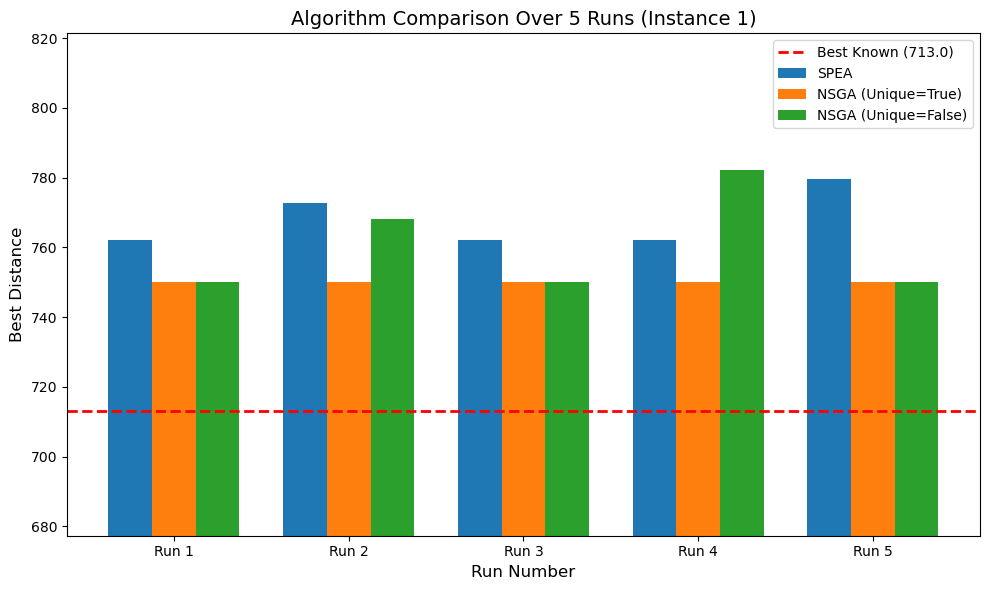

Running tests for Instance 4 over 5 runs...
Testing instance 4 using NSGA II (unique=True)
Average distance over 5 runs: 696.42 (best known: 651.0)
Average diff from known best: 6.52%
Best distance from all runs: 686.4120493034774
Best dispersion from all runs: 26.92582403567252
Best solution: [ 8  2 21 42 10]

Testing instance 4 using NSGA II (unique=False)
Average distance over 5 runs: 689.55 (best known: 651.0)
Average diff from known best: 5.59%
Best distance from all runs: 684.5688725260082
Best dispersion from all runs: 32.89376840679705
Best solution: [15 49  2  7  8]

Testing instance 4 using SPEA II
Average distance over 5 runs: 734.81 (best known: 651.0)
Average diff from known best: 11.41%
Best distance from all runs: 691.5572817416825
Best dispersion from all runs: 24.413111231467404
Best solution: (2, 7, 25, 28, 45)



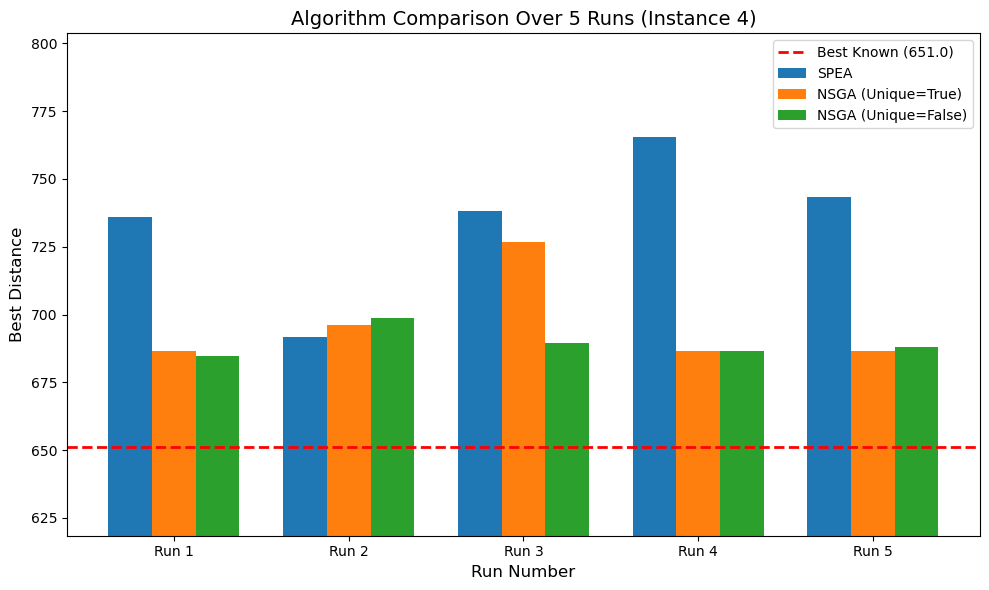

Running tests for Instance 5 over 5 runs...
Testing instance 5 using NSGA II (unique=True)
Average distance over 5 runs: 692.96 (best known: 664.0)
Average diff from known best: 4.18%
Best distance from all runs: 689.8729553107207
Best dispersion from all runs: 36.22154055254967
Best solution: [12 39 28 35 21]

Testing instance 5 using NSGA II (unique=False)
Average distance over 5 runs: 694.47 (best known: 664.0)
Average diff from known best: 4.39%
Best distance from all runs: 689.8729553107207
Best dispersion from all runs: 36.22154055254967
Best solution: [35 39 12 21 28]

Testing instance 5 using SPEA II
Average distance over 5 runs: 707.32 (best known: 664.0)
Average diff from known best: 6.12%
Best distance from all runs: 703.4243048747331
Best dispersion from all runs: 36.22154055254967
Best solution: (21, 24, 28, 35, 39)



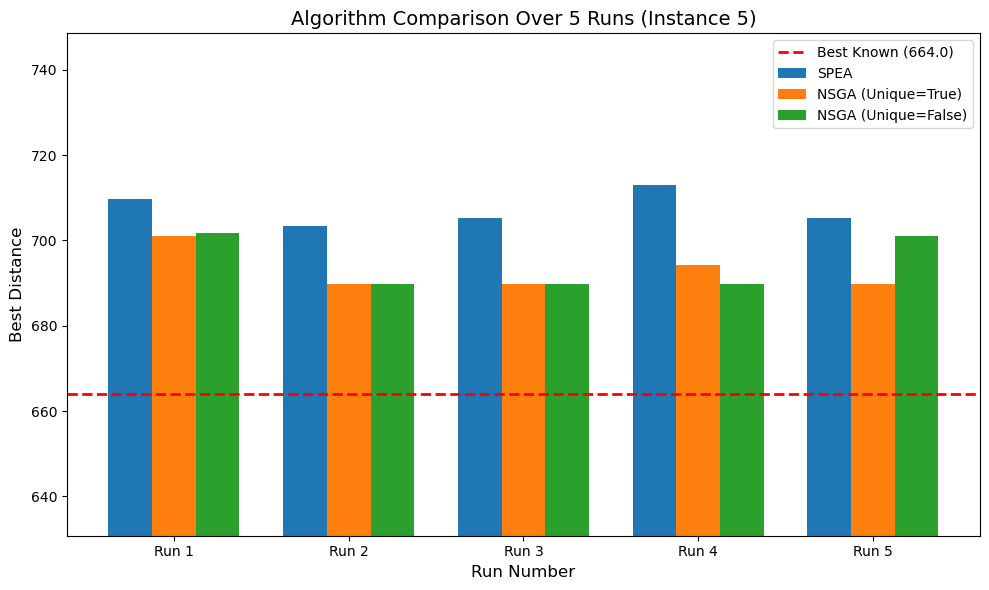

Running tests for Instance 9 over 5 runs...
Testing instance 9 using NSGA II (unique=True)
Average distance over 5 runs: 753.60 (best known: 715.0)
Average diff from known best: 5.12%
Best distance from all runs: 742.0231132133529
Best dispersion from all runs: 27.018512172212592
Best solution: [ 6  8 11 21 22]

Testing instance 9 using NSGA II (unique=False)
Average distance over 5 runs: 751.98 (best known: 715.0)
Average diff from known best: 4.92%
Best distance from all runs: 744.6241297133704
Best dispersion from all runs: 23.08679276123039
Best solution: [ 6 40 12 21 22]

Testing instance 9 using SPEA II
Average distance over 5 runs: 790.32 (best known: 715.0)
Average diff from known best: 9.53%
Best distance from all runs: 744.7016298295489
Best dispersion from all runs: 27.018512172212592
Best solution: (6, 8, 11, 22, 46)



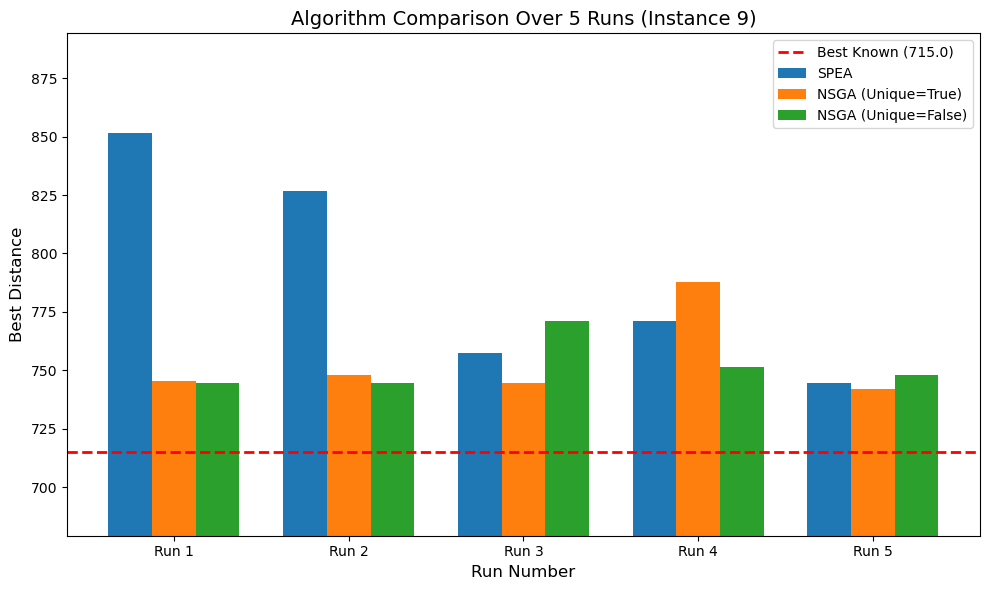

Running tests for Instance 16 over 5 runs...
Testing instance 16 using NSGA II (unique=True)
Average distance over 5 runs: 1115.64 (best known: 954.0)
Average diff from known best: 14.49%
Best distance from all runs: 1051.2409949846322
Best dispersion from all runs: 18.867962264113206
Best solution: [96 65 67 99 70  9 30 23 24 62]

Testing instance 16 using NSGA II (unique=False)
Average distance over 5 runs: 1111.12 (best known: 954.0)
Average diff from known best: 14.14%
Best distance from all runs: 1061.31587157409
Best dispersion from all runs: 17.72004514666935
Best solution: [96  0 34 36  5 70 39 84 54 62]

Testing instance 16 using SPEA II
Average distance over 5 runs: 1094.71 (best known: 954.0)
Average diff from known best: 12.85%
Best distance from all runs: 1041.3903624936897
Best dispersion from all runs: 17.72004514666935
Best solution: (5, 24, 34, 36, 49, 54, 62, 63, 67, 81)



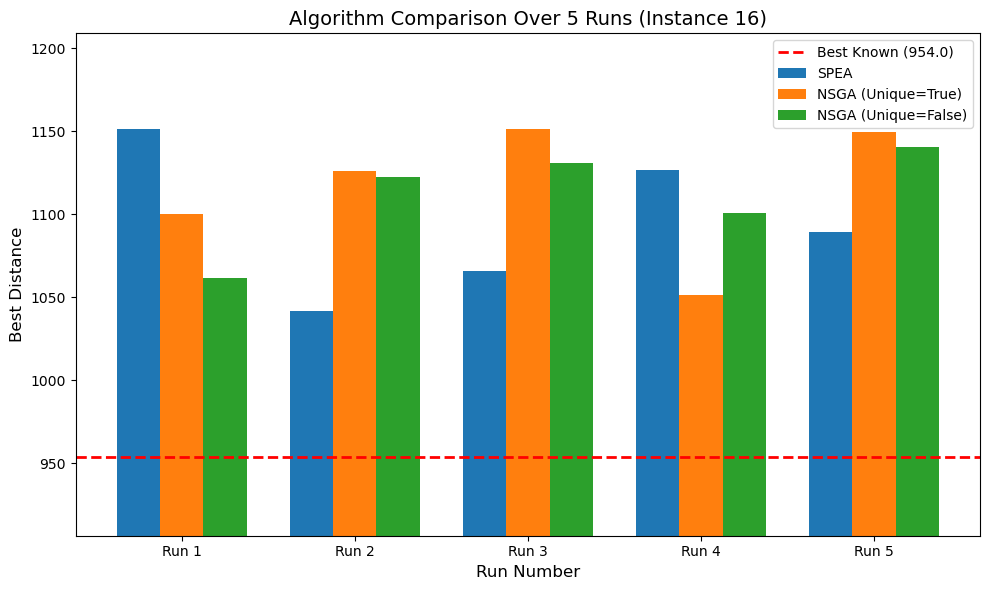

In [9]:
def plot_algorithm_comparison(runs, instance_idx):
    print(f"Running tests for Instance {instance_idx + 1} over {runs} runs...")
    
    # Extract the best known distance
    ins_key = sorted(instances.keys())[instance_idx]
    best_known = instances[ins_key].best_known

    # Run the algorithms and save the returned distances
    nsga_unique_dists = test_nsga(runs, instance=instance_idx, unique=True, quiet=True)
    nsga_non_unique_dists = test_nsga(runs, instance=instance_idx, unique=False, quiet=True)
    spea_dists = test_spea(runs, instance=instance_idx, quiet=True)

    # Setup the bar chart parameters
    x = np.arange(runs)  
    width = 0.25         

    # Create the figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the bars
    ax.bar(x - width, spea_dists, width, label='SPEA')
    ax.bar(x, nsga_unique_dists, width, label='NSGA (Unique=True)')
    ax.bar(x + width, nsga_non_unique_dists, width, label='NSGA (Unique=False)')

    # Add the horizontal reference line
    ax.axhline(y=best_known, color='r', linestyle='--', linewidth=2, label=f'Best Known ({best_known})')

    # Add labels, title, and custom x-axis tick labels
    ax.set_xlabel('Run Number', fontsize=12)
    ax.set_ylabel('Best Distance', fontsize=12)
    ax.set_title(f'Algorithm Comparison Over {runs} Runs (Instance {instance_idx+1})', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Run {i+1}' for i in range(runs)])

    # Adjust the Y-axis minimum to make the differences between bars more obvious
    min_val = min(min(spea_dists), min(nsga_unique_dists), min(nsga_non_unique_dists), best_known)
    ax.set_ylim(bottom=min_val * 0.95) 

    # Render the legend
    ax.legend()
    plt.tight_layout()

    plt.show()

plot_algorithm_comparison(5, 0)
plot_algorithm_comparison(5, 3)
plot_algorithm_comparison(5, 4)
plot_algorithm_comparison(5, 8)
plot_algorithm_comparison(5, 15)

# Conclusions
We can see that each algorithm perform better in different situations. No one of them is always better. When we tried to guarrantee unique children in the NSGA populations, we did not neccessarily improve the resulting best found. We believe that the population became too diverse and fails to hone in on the better solutions. However, the unique version of NSGA tends to be more consistent between runs giving similar results between runs.

Concerning penalty functions, while the NSGA implementation does not strictly guarrantee 0 violations in the final solution, it heavily penalizes solutions with violations. Any solution with a better penalty dominates over solutions with worse penalty, which leads it to quickly disregard infeasible solutions. Our SPEA implementation **does** guarrantee that there are no solutions in the returned pareto front that has any violations. It "kills" any solutions with penalties from the pareto front, but might keep it in the archive.